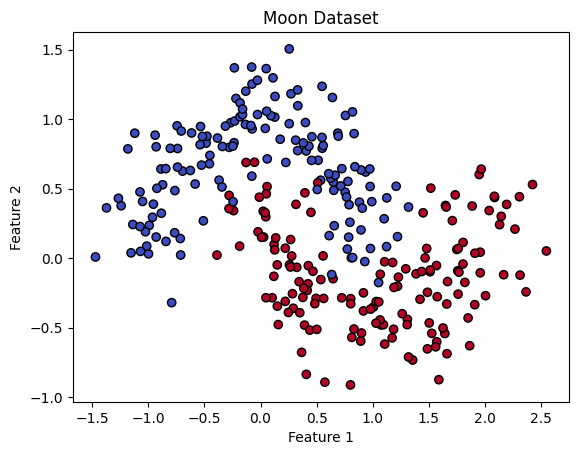

In [2]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y=make_moons(n_samples=300,noise=0.2,random_state=42)

plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',edgecolors='k')
plt.title(("Moon Dataset"))
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Training accuracy: 0.8633333333333333


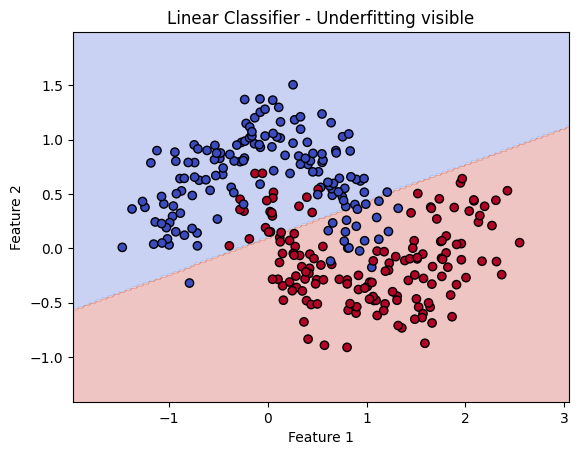

In [3]:
from sklearn.linear_model import LogisticRegression
import numpy as np

linear_model=LogisticRegression()
linear_model.fit(X,y)

x_min,x_max=X[:,0].min()-0.5,X[:,0].max()+0.5
y_min,y_max=X[:,1].min()-0.5,X[:,1].max()+0.5
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.02))

Z=linear_model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)

print("Training accuracy:",linear_model.score(X,y))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Linear Classifier - Underfitting visible")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Training accuracy: 0.97
Improvment in accuracy: 0.1067


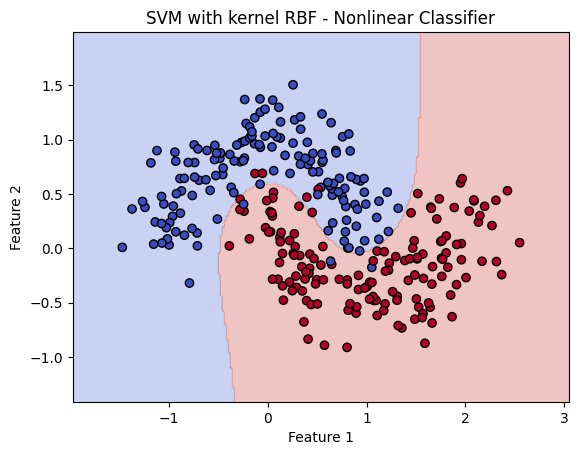

In [4]:
from sklearn.svm import SVC
svm_model=SVC(kernel='rbf',gamma=1.3)
svm_model.fit(X,y)

print("Training accuracy:",svm_model.score(X,y))
print(f"Improvment in accuracy: {svm_model.score(X,y)-linear_model.score(X,y):.4f}")
Z_svm=svm_model.predict(np.c_[xx.ravel(),yy.ravel()])
Z_svm=Z_svm.reshape(xx.shape)

plt.contourf(xx, yy, Z_svm, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("SVM with kernel RBF - Nonlinear Classifier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Training accuracy (Linear): 0.89
Training accuracy (SVM): 1.0
Improvment in accuracy: 0.1100


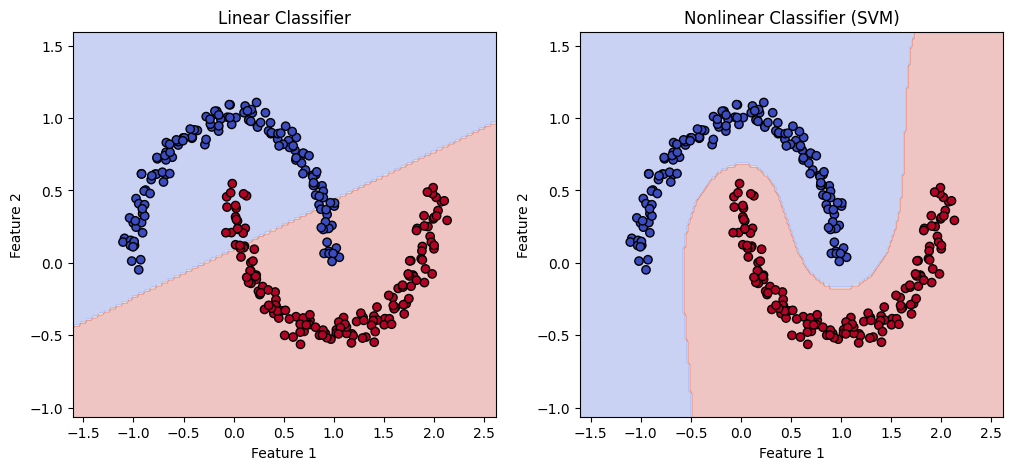

Training accuracy (Linear): 0.8633333333333333
Training accuracy (SVM): 0.97
Improvment in accuracy: 0.1067


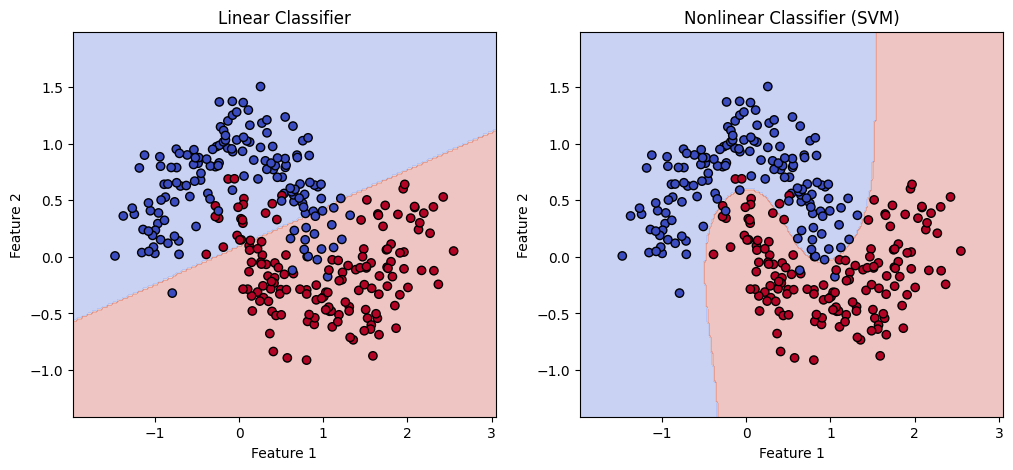

Training accuracy (Linear): 0.8333333333333334
Training accuracy (SVM): 0.8633333333333333
Improvment in accuracy: 0.0300


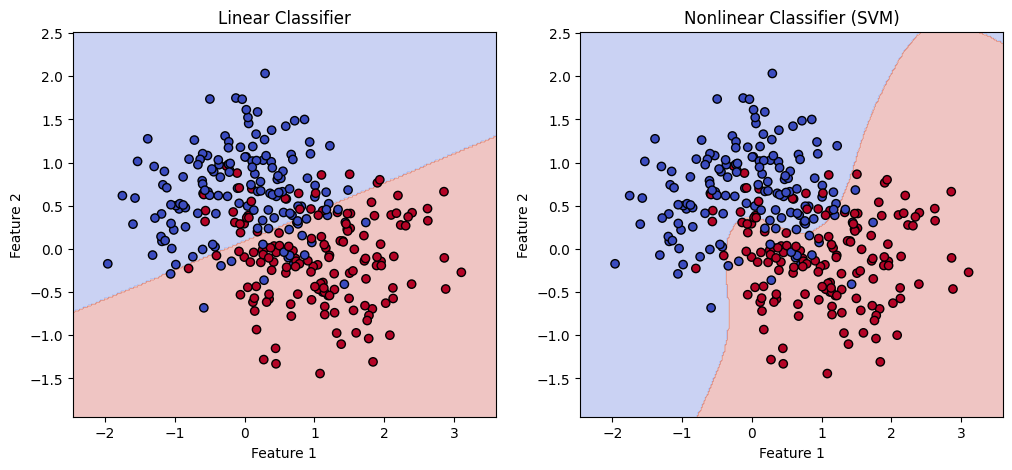

In [35]:
noise_list=[0.05,0.2,0.4]
for noise in noise_list:
  X1, y1=make_moons(n_samples=300,noise=noise,random_state=42)
  fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12, 5))
  linear_model1=LogisticRegression()
  linear_model1.fit(X1,y1)
  svm_model1=SVC(kernel='rbf',gamma=1.3)
  svm_model1.fit(X1,y1)

  x_min1,x_max1=X1[:,0].min()-0.5,X1[:,0].max()+0.5
  y_min1,y_max1=X1[:,1].min()-0.5,X1[:,1].max()+0.5
  xx1,yy1=np.meshgrid(np.arange(x_min1,x_max1,0.02),
                      np.arange(y_min1,y_max1,0.02))

  Z1=linear_model.predict(np.c_[xx1.ravel(),yy1.ravel()])
  Z1=Z1.reshape(xx1.shape)
  Z_svm1=svm_model1.predict(np.c_[xx1.ravel(),yy1.ravel()])
  Z_svm1=Z_svm1.reshape(xx1.shape)

  print("Training accuracy (Linear):",linear_model1.score(X1,y1))
  print("Training accuracy (SVM):",svm_model1.score(X1,y1))
  print(f"Improvment in accuracy: {svm_model1.score(X1,y1)-linear_model1.score(X1,y1):.4f}")

  ax1.contourf(xx1,yy1,Z1,alpha=0.3,cmap='coolwarm')
  ax1.scatter(X1[:,0],X1[:,1],c=y,cmap='coolwarm',edgecolors='k')
  ax1.set_title("Linear Classifier")
  ax1.set_xlabel("Feature 1")
  ax1.set_ylabel("Feature 2")
  ax2.contourf(xx1,yy1,Z_svm1,alpha=0.3,cmap='coolwarm')
  ax2.scatter(X1[:,0],X1[:,1],c=y,cmap='coolwarm',edgecolors='k')
  ax2.set_title("Nonlinear Classifier (SVM)")
  ax2.set_xlabel("Feature 1")
  ax2.set_ylabel("Feature 2")
  plt.show()

Training accuracy: 0.8633


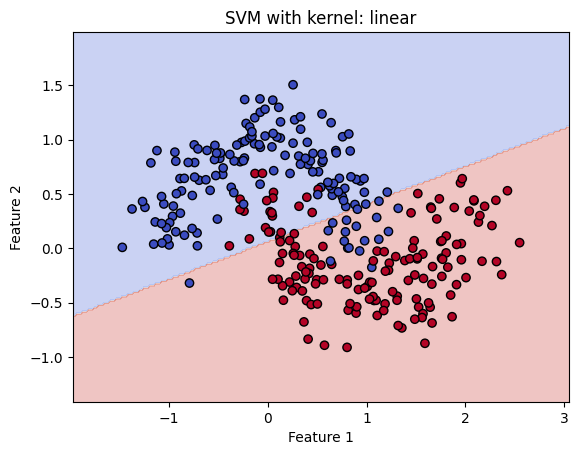

Training accuracy: 0.9067


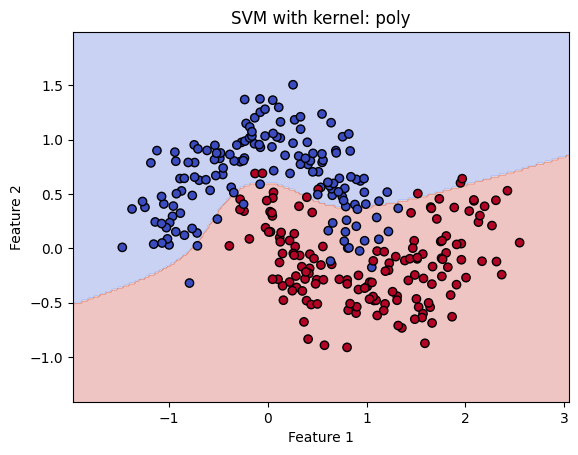

Training accuracy: 0.9600


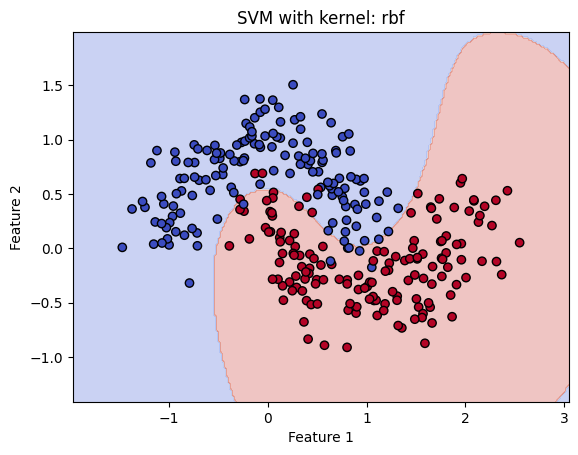

In [6]:
kernel_list=['linear','poly','rbf']
for kernel in kernel_list:
  svm_model2=SVC(kernel=kernel,gamma='scale')
  svm_model2.fit(X,y)

  print(f"Training accuracy: {svm_model2.score(X,y):.4f}")
  Z_svm2=svm_model2.predict(np.c_[xx.ravel(),yy.ravel()])
  Z_svm2=Z_svm2.reshape(xx.shape)

  plt.contourf(xx, yy, Z_svm2, alpha=0.3, cmap='coolwarm')
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
  plt.title(f"SVM with kernel: {kernel}")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.show()

Accuracy (Linear): 0.8633
Accuracy (Polynomial Transformation): 0.9267
Improvement: 0.0633


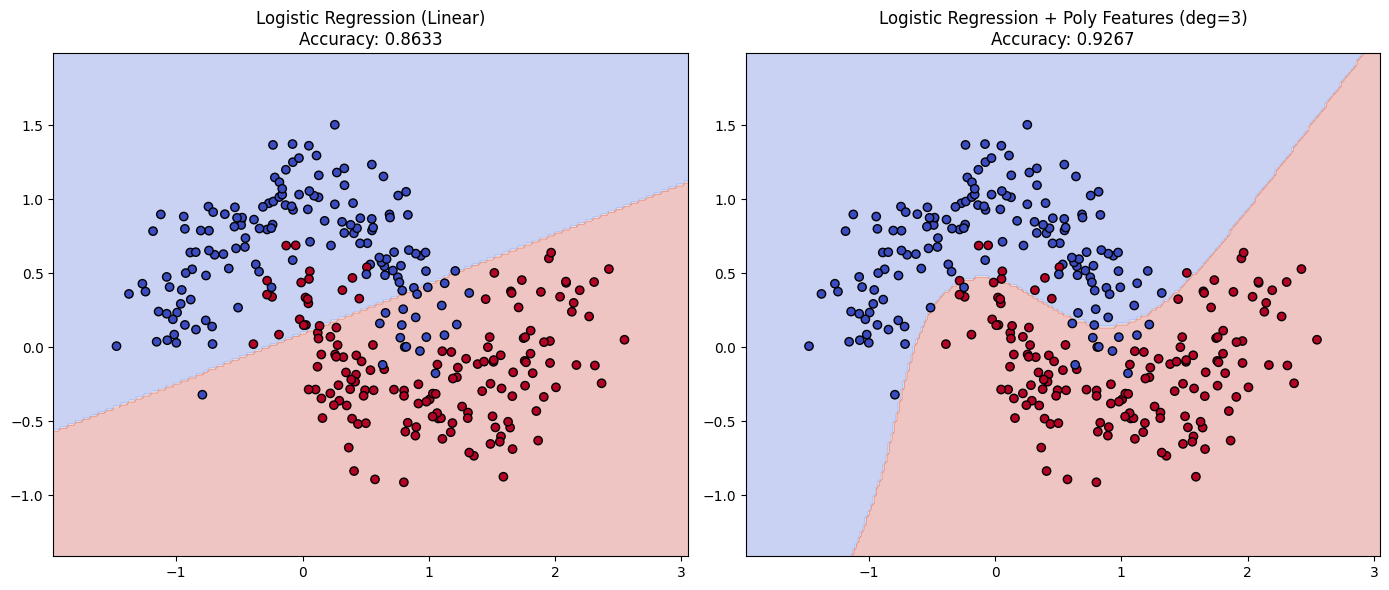

In [14]:
from sklearn.preprocessing import PolynomialFeatures

model_lin=LogisticRegression()
model_lin.fit(X,y)
Z_lin=model_lin.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
poly=PolynomialFeatures(degree=3)
X_poly=poly.fit_transform(X)
model_poly=LogisticRegression()
model_poly.fit(X_poly, y)

grid_points_poly=poly.transform(np.c_[xx.ravel(),yy.ravel()])
Z_poly=model_poly.predict(grid_points_poly).reshape(xx.shape)
acc_lin=model_lin.score(X,y)
acc_poly=model_poly.score(X_poly,y)

print(f"Accuracy (Linear): {acc_lin:.4f}")
print(f"Accuracy (Polynomial Transformation): {acc_poly:.4f}")
print(f"Improvement: {acc_poly-acc_lin:.4f}")

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,6))
ax1.contourf(xx,yy,Z_lin,alpha=0.3,cmap='coolwarm')
ax1.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',edgecolors='k')
ax1.set_title(f"Logistic Regression (Linear)\nAccuracy: {acc_lin:.4f}")

ax2.contourf(xx,yy,Z_poly,alpha=0.3,cmap='coolwarm')
ax2.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',edgecolors='k')
ax2.set_title(f"Logistic Regression + Poly Features (deg=3)\nAccuracy: {acc_poly:.4f}")
plt.tight_layout()
plt.show()

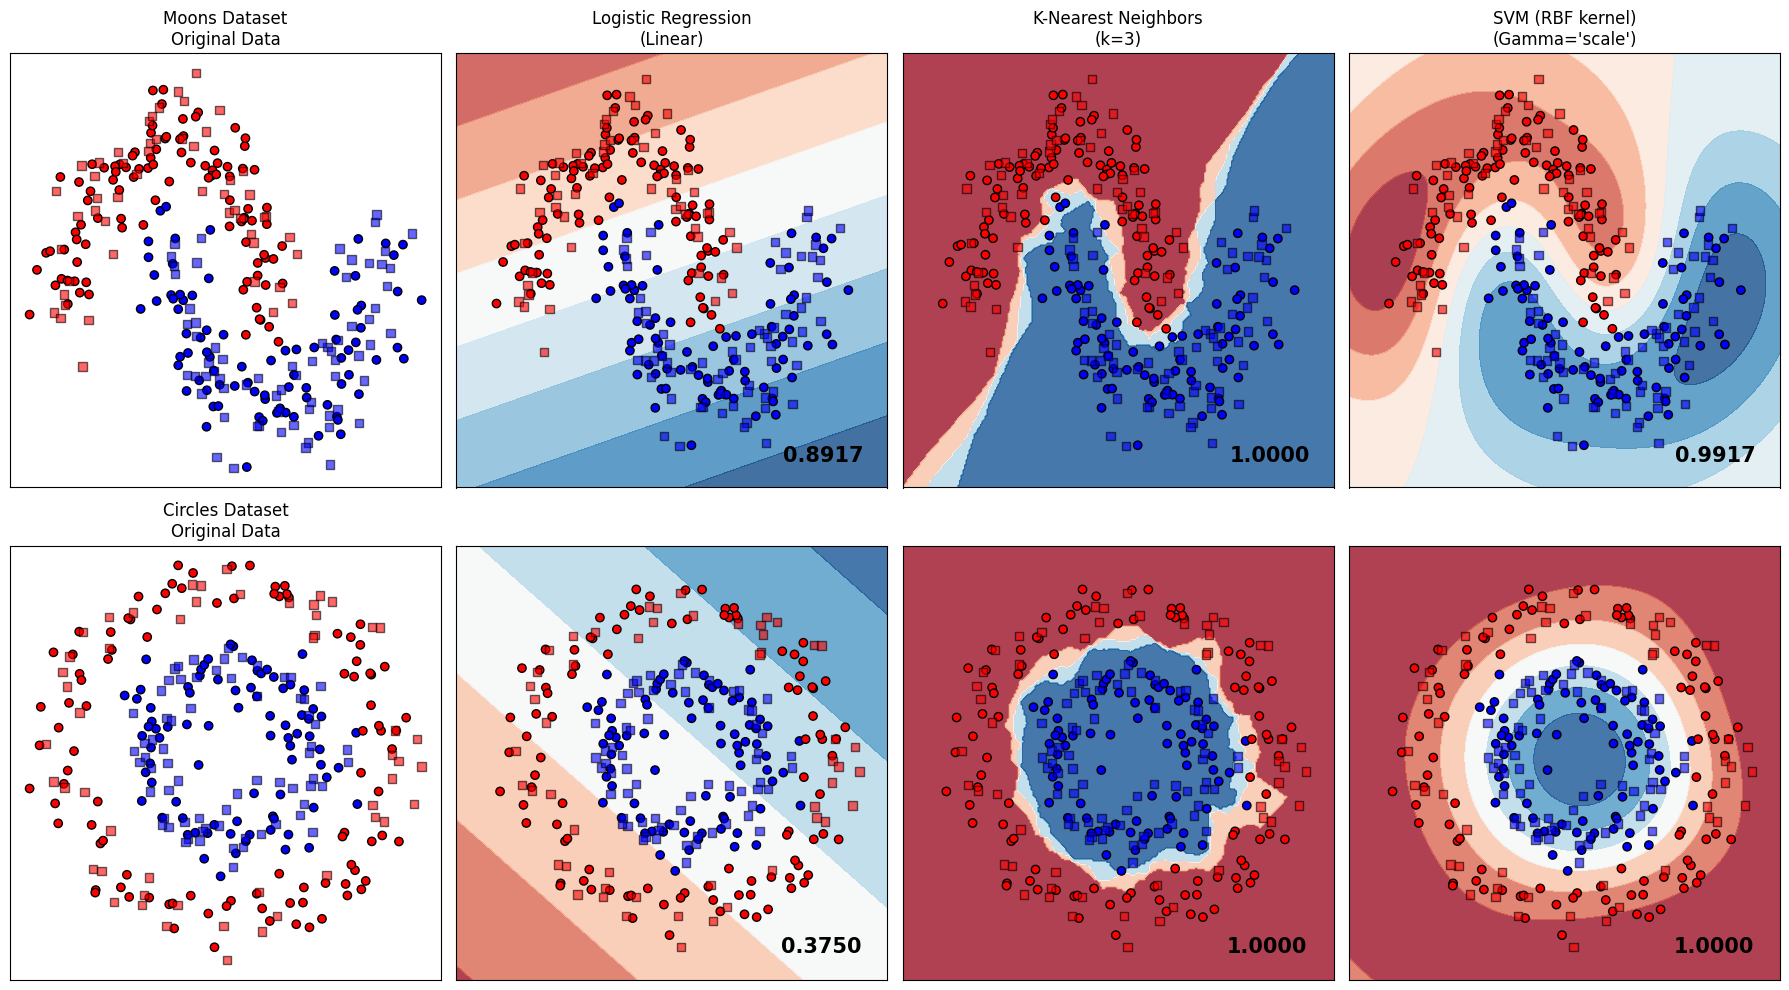

In [34]:
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

datasets=[(make_moons(n_samples=300,noise=0.15,random_state=42),"Moons Dataset"),
 (make_circles(n_samples=300,noise=0.1,factor=0.5,random_state=42),"Circles Dataset")]
names=["Logistic Regression\n(Linear)","K-Nearest Neighbors\n(k=3)","SVM (RBF kernel)\n(Gamma='scale')"]
classifiers=[LogisticRegression(),KNeighborsClassifier(3),SVC(kernel="rbf",gamma='scale',probability=True)]
figure=plt.figure(figsize=(18, 10))
row=0
for (X, y), ds_name in datasets:
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)
    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train)
    X_test=scaler.transform(X_test)
    h=.02
    x_min,x_max=X_train[:,0].min()-.5,X_train[:,0].max()+.5
    y_min,y_max=X_train[:,1].min()-.5,X_train[:,1].max()+.5
    xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
    cm=plt.cm.RdBu
    cm_bright=ListedColormap(['#FF0000','#0000FF'])
    i=row*(len(classifiers)+1)+1
    ax=plt.subplot(2, len(classifiers) + 1, i)
    ax.set_title(f"{ds_name}\nOriginal Data")
    ax.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap=cm_bright,edgecolors='k')
    ax.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap=cm_bright,alpha=0.6,edgecolors='k',marker='s')
    ax.set_xticks(())
    ax.set_yticks(())
    for name,clf in zip(names,classifiers):
        i+=1
        ax=plt.subplot(2,len(classifiers)+1,i)
        clf.fit(X_train,y_train)
        score=clf.score(X_test,y_test)
        if hasattr(clf,"decision_function"):
            Z=clf.decision_function(np.c_[xx.ravel(),yy.ravel()])
        else:
            Z=clf.predict_proba(np.c_[xx.ravel(),yy.ravel()])[:,1]
        Z=Z.reshape(xx.shape)
        ax.contourf(xx,yy,Z,cmap=cm,alpha=.8)
        ax.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap=cm_bright,edgecolors='k')
        ax.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap=cm_bright,edgecolors='k',alpha=0.6,marker='s')
        ax.set_xlim(xx.min(),xx.max())
        ax.set_ylim(yy.min(),yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if row==0:ax.set_title(name)
        ax.text(xx.max()-.3,yy.min()+.3,('%.4f'%score),size=15,horizontalalignment='right',weight='bold')
    row+=1
plt.tight_layout()
plt.show()